# Statistical Tests — All Datasets

This notebook validates the geometric features with three formal tests,
run at the **benchmark level** (≈500 questions each) and for the **combined dataset**
(2500 questions). Tests are **not** run per domain (see caveat in eda.ipynb).

---

## Statistical Test Guide

### 1. Two-Sample Kolmogorov-Smirnov (KS) Test

**What are we testing?**
For each of the 5 geometric features separately, we ask: *is the distribution of this
feature different between hallucinated questions (label=1) and correct questions (label=0)?*

**Null hypothesis H₀:** The feature x_k has the same distribution in both groups.

**Test statistic:** D_n = sup_x |F̂_{y=1}(x) − F̂_{y=0}(x)| — the largest vertical gap
between the two empirical CDFs at any threshold x.

**Interpretation:**
- D_n ≈ 0.1–0.2: small separation; feature provides a weak signal.
- D_n ≈ 0.3–0.4: moderate separation; feature is meaningful.
- D_n > 0.5: strong separation; feature reliably distinguishes the classes.
- We apply **Bonferroni correction** (α_adj = 0.05/5 = 0.01) since we test 5 features (we are working on understanding it)
  A feature marked ✓ is significant after this adjustment.

---

### 2. Permutation Test on Mean Entropy Difference

**What are we testing?**
*Does hallucinated questions have higher semantic entropy than correct questions?*
This directly tests the core claim of Farquhar et al. (2024).

**Null hypothesis H₀:** The mean semantic entropy is the same for hallucinated
and correct questions — i.e., entropy carries no signal.

**Procedure:** Compute observed Δ = mean(H | y=1) − mean(H | y=0). Then shuffle the
labels 10 000 times to build a null distribution of Δ values under H₀.

**p-value:** Fraction of permutations yielding Δ ≥ Δ_obs (one-sided).

**Interpretation:**
- p < 0.001: very strong evidence that hallucinated questions have higher entropy.
- The histogram shows the null distribution (grey) vs. the observed delta (red dashed).
  A red line far in the right tail → entropy is a real signal, not noise.

---

### 3. Bootstrap Confidence Interval on AUC-ROC

**What are we testing?**
*How reliably does the Random Forest distinguish hallucinated from correct questions?
Is its AUC significantly above chance?*

**Null hypothesis H₀ (implicit):** AUC = 0.5 (classifier performs at chance).

**Procedure:** Draw B=2 000 bootstrap samples (with replacement). For each, train an RF
on the in-bag set and score the out-of-bag (OOB) set. Collect all OOB AUC values and
report the 2.5th–97.5th percentile as the 95% confidence interval.

**Interpretation:**
- 95% CI entirely above 0.5: the classifier reliably outperforms chance.
- Narrow CI (width < 0.10): performance is stable across resamples — results are not
  driven by a lucky draw of questions.
- Wide CI: more uncertainty; larger dataset or more discriminative features needed.
- We run bootstrap on **full benchmarks and combined only** — per-domain sub-groups
  are too small for stable OOB sets.


## Setup

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from spectral_detection.data.cleaning import GEO_FEATURES
from spectral_detection.analysis.stats import (
    run_global_ks_tests, run_permutation_test, run_bootstrap_auc,
)
from spectral_detection.visualization import (
    plot_permutation_test, plot_bootstrap_auc,
)


## Configuration

In [2]:
CSV_DIR    = '../data/temp/processed_csv/'
OUTPUT_DIR = '../data/processed/temp/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

N_PERMUTATIONS = 10000
N_BOOTSTRAP    = 2000
RANDOM_SEED    = 42


## Load Feature DataFrames


In [3]:
feat_dfs = {}
for ds in ['defan', 'halueval', 'mmlu', 'triviaqa', 'truthfulqa']:
    feat_dfs[ds] = pd.read_csv(os.path.join(CSV_DIR, f'{ds}_features.csv'))
    print(f'{ds:12s}: {len(feat_dfs[ds]):4d} questions, hallu rate={feat_dfs[ds]["label"].mean()*100:.1f}%')
feat_all = pd.read_csv(os.path.join(CSV_DIR, 'combined_features.csv'))
print(f'combined  : {len(feat_all):4d} questions, hallu rate={feat_all["label"].mean()*100:.1f}%')


defan       :  500 questions, hallu rate=79.6%
halueval    :  500 questions, hallu rate=7.2%
mmlu        :  500 questions, hallu rate=78.4%
triviaqa    :  500 questions, hallu rate=41.6%
truthfulqa  :  500 questions, hallu rate=72.0%
combined  : 2500 questions, hallu rate=55.8%


---
## DEFAN


### DEFAN: KS Tests


In [4]:
df_ks_defan = run_global_ks_tests(feat_dfs['defan'])
df_ks_defan.to_csv(os.path.join(OUTPUT_DIR, 'defan_ks_global.csv'), index=False)
display(df_ks_defan)


Global KS tests  (Bonferroni α = 0.0071, n_tests = 7):
  ✓  H_sem         D=0.6274  p=7.75e-31  ***
  ✓  D_cos         D=0.5487  p=3.62e-23  ***
     D_cos_var     D=0.1069  p=2.87e-01  ns
  ✓  D_pair        D=0.5487  p=3.62e-23  ***
  ✓  M_bar         D=0.6603  p=1.86e-34  ***
  ✓  K             D=0.6005  p=4.78e-28  ***
     sig2_S        D=0.1624  p=2.40e-02  *


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.6274,7.750062e-31,***,True
1,D_cos,0.5487,3.624887e-23,***,True
2,D_cos_var,0.1069,2.871090e-01,ns,False
3,D_pair,0.5487,3.624887e-23,***,True
4,M_bar,0.6603,1.864071e-34,***,True
5,K,0.6005,4.779461e-28,***,True
6,sig2_S,0.1624,2.403701e-02,*,False


A feature with **Significant=True** has a distribution that differs between hallucinated and correct questions after Bonferroni correction (α=0.01). H_sem (semantic entropy) should show the strongest signal per Farquhar et al. (2024).


### DEFAN: Permutation Test


Permutation test (10000 iterations):
  Observed Δ = 1.6747 bits
  p-value    = 0.000000


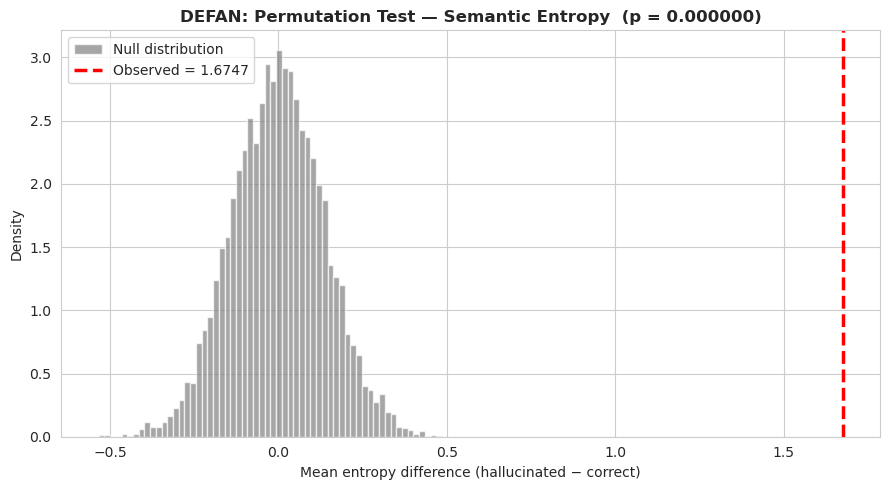

In [5]:
delta_defan, perm_d_defan, pval_defan = run_permutation_test(
    feat_dfs['defan'],
    n_permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(perm_d_defan, delta_defan,
                            N_PERMUTATIONS, pval_defan,
                            title='DEFAN: Permutation Test — Semantic Entropy')
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


### DEFAN: Bootstrap AUC


Bootstrap AUC (RF, 7 geometric features, B=2000):
  AUC = 0.9051  95% CI [0.8635, 0.9404]


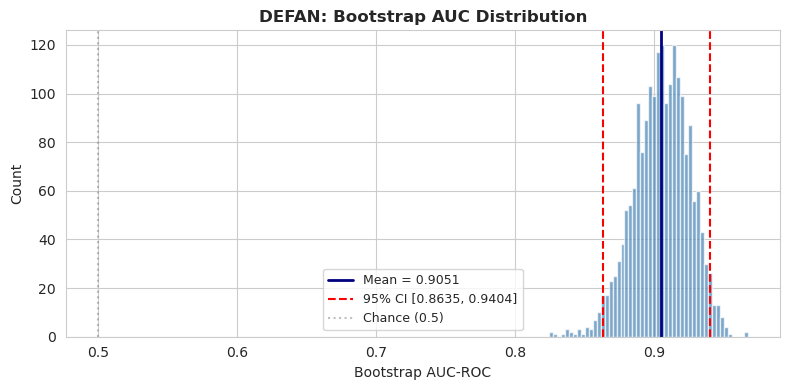

In [6]:
auc_boot_defan, ci_lo_defan, ci_hi_defan = run_bootstrap_auc(
    feat_dfs['defan'],
    n_bootstrap=N_BOOTSTRAP,
    random_seed=RANDOM_SEED,
)
fig = plot_bootstrap_auc(auc_boot_defan, ci_lo_defan, ci_hi_defan,
                         dataset_name='DEFAN')
plt.savefig(os.path.join(OUTPUT_DIR, 'defan_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## HALUEVAL


### HALUEVAL: KS Tests


In [7]:
df_ks_halueval = run_global_ks_tests(feat_dfs['halueval'])
df_ks_halueval.to_csv(os.path.join(OUTPUT_DIR, 'halueval_ks_global.csv'), index=False)
display(df_ks_halueval)


Global KS tests  (Bonferroni α = 0.0071, n_tests = 7):
  ✓  H_sem         D=0.4770  p=1.75e-07  ***
  ✓  D_cos         D=0.5417  p=1.18e-09  ***
  ✓  D_cos_var     D=0.5556  p=3.50e-10  ***
  ✓  D_pair        D=0.5417  p=1.18e-09  ***
  ✓  M_bar         D=0.5649  p=1.56e-10  ***
  ✓  K             D=0.4571  p=6.92e-07  ***
  ✓  sig2_S        D=0.6025  p=4.69e-12  ***


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.4770,1.748237e-07,***,True
1,D_cos,0.5417,1.178612e-09,***,True
2,D_cos_var,0.5556,3.503507e-10,***,True
3,D_pair,0.5417,1.178612e-09,***,True
4,M_bar,0.5649,1.556577e-10,***,True
5,K,0.4571,6.920703e-07,***,True
6,sig2_S,0.6025,4.692467e-12,***,True


A feature with **Significant=True** has a distribution that differs between hallucinated and correct questions after Bonferroni correction (α=0.01). H_sem (semantic entropy) should show the strongest signal per Farquhar et al. (2024).


### HALUEVAL: Permutation Test


Permutation test (10000 iterations):
  Observed Δ = 1.2933 bits
  p-value    = 0.000000


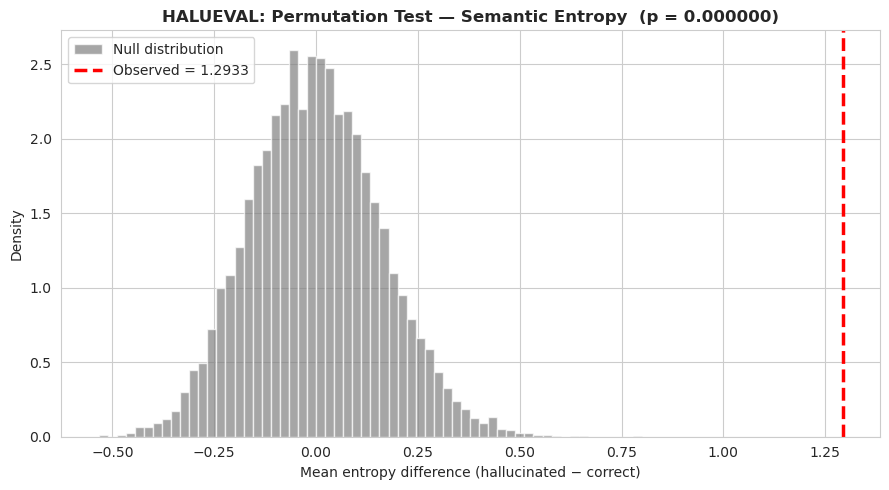

In [8]:
delta_halueval, perm_d_halueval, pval_halueval = run_permutation_test(
    feat_dfs['halueval'],
    n_permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(perm_d_halueval, delta_halueval,
                            N_PERMUTATIONS, pval_halueval,
                            title='HALUEVAL: Permutation Test — Semantic Entropy')
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


### HALUEVAL: Bootstrap AUC


Bootstrap AUC (RF, 7 geometric features, B=2000):
  AUC = 0.8688  95% CI [0.7846, 0.9414]


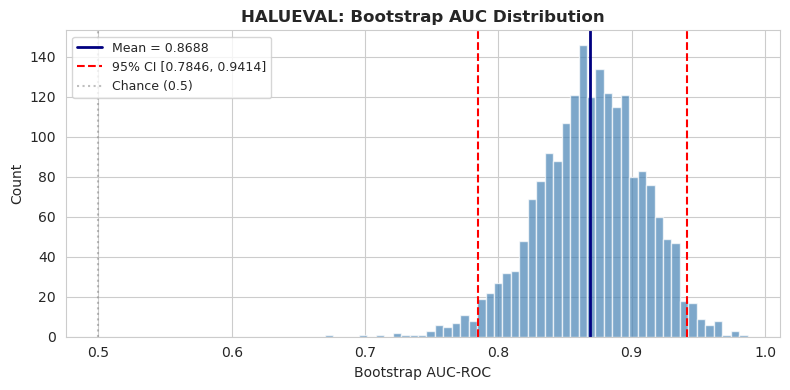

In [9]:
auc_boot_halueval, ci_lo_halueval, ci_hi_halueval = run_bootstrap_auc(
    feat_dfs['halueval'],
    n_bootstrap=N_BOOTSTRAP,
    random_seed=RANDOM_SEED,
)
fig = plot_bootstrap_auc(auc_boot_halueval, ci_lo_halueval, ci_hi_halueval,
                         dataset_name='HALUEVAL')
plt.savefig(os.path.join(OUTPUT_DIR, 'halueval_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## MMLU


### MMLU: KS Tests


In [10]:
df_ks_mmlu = run_global_ks_tests(feat_dfs['mmlu'])
df_ks_mmlu.to_csv(os.path.join(OUTPUT_DIR, 'mmlu_ks_global.csv'), index=False)
display(df_ks_mmlu)


Global KS tests  (Bonferroni α = 0.0071, n_tests = 7):
  ✓  H_sem         D=0.3076  p=1.34e-07  ***
  ✓  D_cos         D=0.3063  p=1.55e-07  ***
     D_cos_var     D=0.0766  p=6.69e-01  ns
  ✓  D_pair        D=0.3063  p=1.55e-07  ***
  ✓  M_bar         D=0.7349  p=1.17e-45  ***
  ✓  K             D=0.3060  p=1.60e-07  ***
     sig2_S        D=0.0834  p=5.64e-01  ns


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.3076,1.344803e-07,***,True
1,D_cos,0.3063,1.552311e-07,***,True
2,D_cos_var,0.0766,6.689627e-01,ns,False
3,D_pair,0.3063,1.552311e-07,***,True
4,M_bar,0.7349,1.166094e-45,***,True
5,K,0.3060,1.600439e-07,***,True
6,sig2_S,0.0834,5.639895e-01,ns,False


A feature with **Significant=True** has a distribution that differs between hallucinated and correct questions after Bonferroni correction (α=0.01). H_sem (semantic entropy) should show the strongest signal per Farquhar et al. (2024).


### MMLU: Permutation Test


Permutation test (10000 iterations):
  Observed Δ = 0.3847 bits
  p-value    = 0.000000


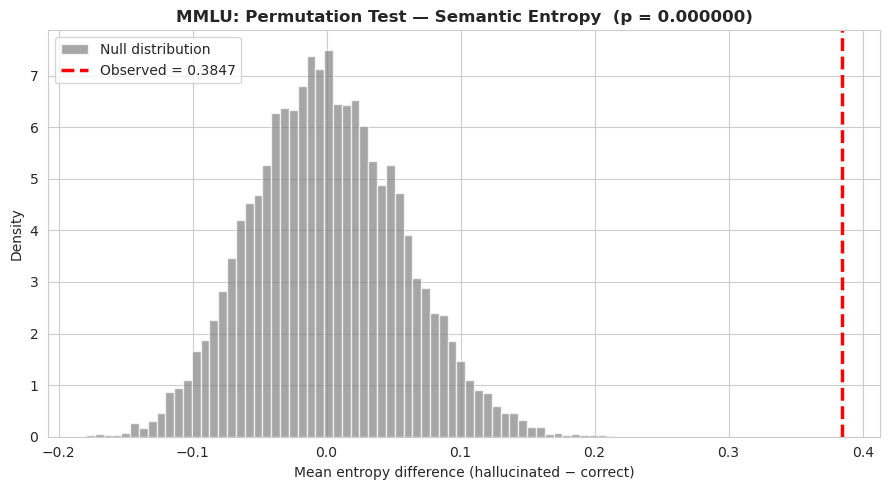

In [11]:
delta_mmlu, perm_d_mmlu, pval_mmlu = run_permutation_test(
    feat_dfs['mmlu'],
    n_permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(perm_d_mmlu, delta_mmlu,
                            N_PERMUTATIONS, pval_mmlu,
                            title='MMLU: Permutation Test — Semantic Entropy')
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


### MMLU: Bootstrap AUC


Bootstrap AUC (RF, 7 geometric features, B=2000):
  AUC = 0.9022  95% CI [0.8463, 0.9471]


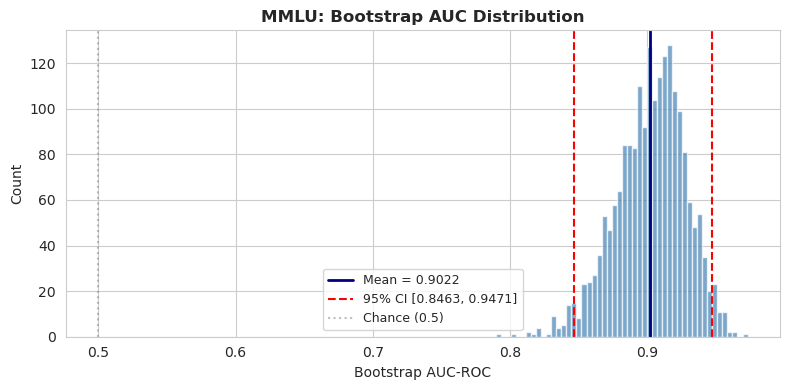

In [12]:
auc_boot_mmlu, ci_lo_mmlu, ci_hi_mmlu = run_bootstrap_auc(
    feat_dfs['mmlu'],
    n_bootstrap=N_BOOTSTRAP,
    random_seed=RANDOM_SEED,
)
fig = plot_bootstrap_auc(auc_boot_mmlu, ci_lo_mmlu, ci_hi_mmlu,
                         dataset_name='MMLU')
plt.savefig(os.path.join(OUTPUT_DIR, 'mmlu_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## TRIVIAQA


### TRIVIAQA: KS Tests


In [13]:
df_ks_triviaqa = run_global_ks_tests(feat_dfs['triviaqa'])
df_ks_triviaqa.to_csv(os.path.join(OUTPUT_DIR, 'triviaqa_ks_global.csv'), index=False)
display(df_ks_triviaqa)


Global KS tests  (Bonferroni α = 0.0071, n_tests = 7):
  ✓  H_sem         D=0.6640  p=2.32e-51  ***
  ✓  D_cos         D=0.6811  p=2.66e-54  ***
  ✓  D_cos_var     D=0.4594  p=1.12e-23  ***
  ✓  D_pair        D=0.6811  p=2.66e-54  ***
  ✓  M_bar         D=0.8882  p=1.51e-101  ***
  ✓  K             D=0.6310  p=5.88e-46  ***
  ✓  sig2_S        D=0.4731  p=3.86e-25  ***


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.6640,2.322796e-51,***,True
1,D_cos,0.6811,2.658822e-54,***,True
2,D_cos_var,0.4594,1.118056e-23,***,True
3,D_pair,0.6811,2.658822e-54,***,True
4,M_bar,0.8882,1.510046e-101,***,True
5,K,0.6310,5.880889e-46,***,True
6,sig2_S,0.4731,3.863526e-25,***,True


A feature with **Significant=True** has a distribution that differs between hallucinated and correct questions after Bonferroni correction (α=0.01). H_sem (semantic entropy) should show the strongest signal per Farquhar et al. (2024).


### TRIVIAQA: Permutation Test


Permutation test (10000 iterations):
  Observed Δ = 2.0118 bits
  p-value    = 0.000000


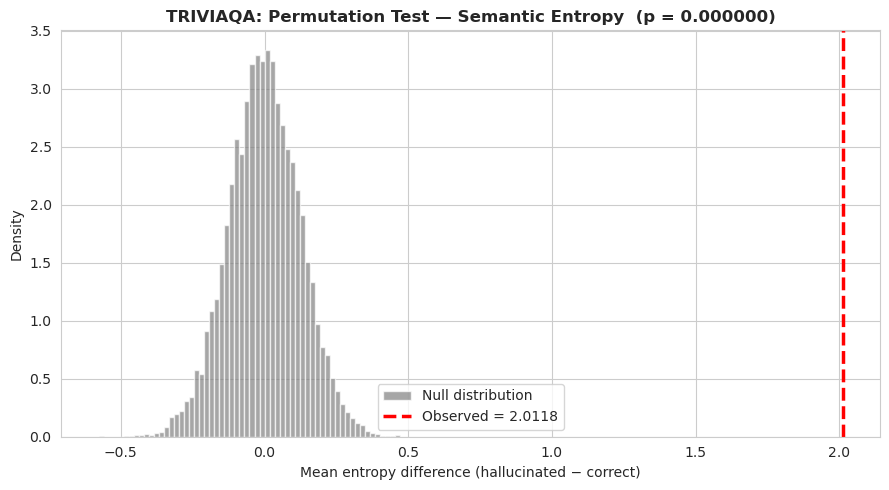

In [14]:
delta_triviaqa, perm_d_triviaqa, pval_triviaqa = run_permutation_test(
    feat_dfs['triviaqa'],
    n_permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(perm_d_triviaqa, delta_triviaqa,
                            N_PERMUTATIONS, pval_triviaqa,
                            title='TRIVIAQA: Permutation Test — Semantic Entropy')
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRIVIAQA: Bootstrap AUC


Bootstrap AUC (RF, 7 geometric features, B=2000):
  AUC = 0.9681  95% CI [0.9458, 0.9879]


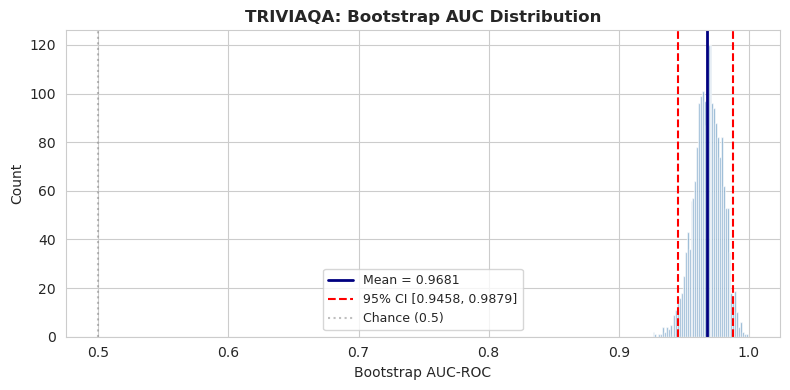

In [15]:
auc_boot_triviaqa, ci_lo_triviaqa, ci_hi_triviaqa = run_bootstrap_auc(
    feat_dfs['triviaqa'],
    n_bootstrap=N_BOOTSTRAP,
    random_seed=RANDOM_SEED,
)
fig = plot_bootstrap_auc(auc_boot_triviaqa, ci_lo_triviaqa, ci_hi_triviaqa,
                         dataset_name='TRIVIAQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'triviaqa_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## TRUTHFULQA


### TRUTHFULQA: KS Tests


In [16]:
df_ks_truthfulqa = run_global_ks_tests(feat_dfs['truthfulqa'])
df_ks_truthfulqa.to_csv(os.path.join(OUTPUT_DIR, 'truthfulqa_ks_global.csv'), index=False)
display(df_ks_truthfulqa)


Global KS tests  (Bonferroni α = 0.0071, n_tests = 7):
  ✓  H_sem         D=0.3929  p=1.98e-14  ***
  ✓  D_cos         D=0.3762  p=3.06e-13  ***
     D_cos_var     D=0.1421  p=3.06e-02  *
  ✓  D_pair        D=0.3762  p=3.06e-13  ***
  ✓  M_bar         D=0.8107  p=6.19e-68  ***
  ✓  K             D=0.3687  p=1.01e-12  ***
     sig2_S        D=0.1552  p=1.38e-02  *


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.3929,1.975201e-14,***,True
1,D_cos,0.3762,3.060980e-13,***,True
2,D_cos_var,0.1421,3.061996e-02,*,False
3,D_pair,0.3762,3.060980e-13,***,True
4,M_bar,0.8107,6.194697e-68,***,True
5,K,0.3687,1.012690e-12,***,True
6,sig2_S,0.1552,1.377505e-02,*,False


A feature with **Significant=True** has a distribution that differs between hallucinated and correct questions after Bonferroni correction (α=0.01). H_sem (semantic entropy) should show the strongest signal per Farquhar et al. (2024).


### TRUTHFULQA: Permutation Test


Permutation test (10000 iterations):
  Observed Δ = 1.1194 bits
  p-value    = 0.000000


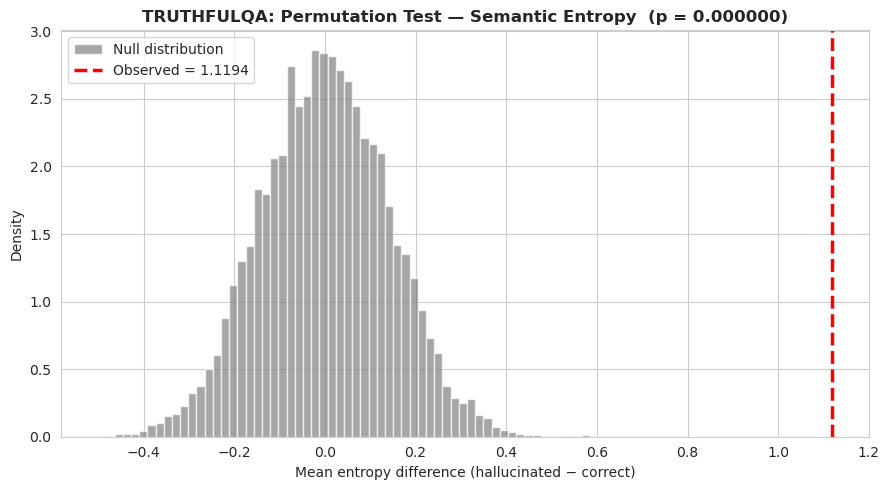

In [17]:
delta_truthfulqa, perm_d_truthfulqa, pval_truthfulqa = run_permutation_test(
    feat_dfs['truthfulqa'],
    n_permutations=N_PERMUTATIONS,
    random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(perm_d_truthfulqa, delta_truthfulqa,
                            N_PERMUTATIONS, pval_truthfulqa,
                            title='TRUTHFULQA: Permutation Test — Semantic Entropy')
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


### TRUTHFULQA: Bootstrap AUC


Bootstrap AUC (RF, 7 geometric features, B=2000):
  AUC = 0.9223  95% CI [0.8851, 0.9559]


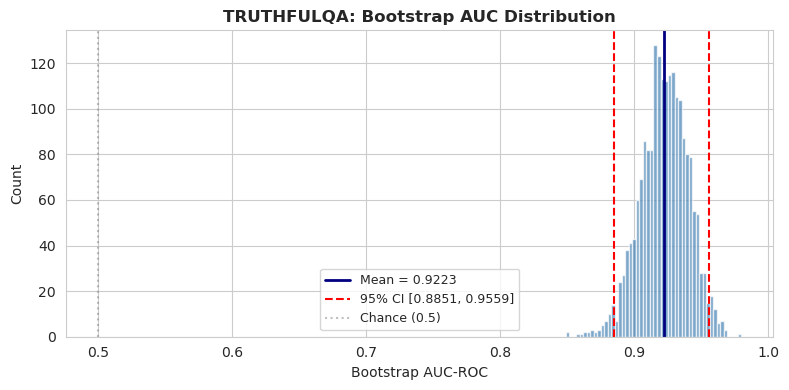

In [18]:
auc_boot_truthfulqa, ci_lo_truthfulqa, ci_hi_truthfulqa = run_bootstrap_auc(
    feat_dfs['truthfulqa'],
    n_bootstrap=N_BOOTSTRAP,
    random_seed=RANDOM_SEED,
)
fig = plot_bootstrap_auc(auc_boot_truthfulqa, ci_lo_truthfulqa, ci_hi_truthfulqa,
                         dataset_name='TRUTHFULQA')
plt.savefig(os.path.join(OUTPUT_DIR, 'truthfulqa_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Combined Dataset — All 2500 Questions


### Combined: KS Tests


In [19]:
df_ks_all = run_global_ks_tests(feat_all)
df_ks_all.to_csv(os.path.join(OUTPUT_DIR, 'combined_ks_global.csv'), index=False)
display(df_ks_all)


Global KS tests  (Bonferroni α = 0.0071, n_tests = 7):
  ✓  H_sem         D=0.5927  p=9.80e-202  ***
  ✓  D_cos         D=0.5603  p=5.87e-179  ***
  ✓  D_cos_var     D=0.3323  p=8.21e-61  ***
  ✓  D_pair        D=0.5603  p=5.87e-179  ***
  ✓  M_bar         D=0.5760  p=9.47e-190  ***
  ✓  K             D=0.5792  p=5.17e-192  ***
  ✓  sig2_S        D=0.3382  p=4.84e-63  ***


,Feature,KS_stat,p_value,sig,Significant
0,H_sem,0.5927,9.803422e-202,***,True
1,D_cos,0.5603,5.868546e-179,***,True
2,D_cos_var,0.3323,8.211381e-61,***,True
3,D_pair,0.5603,5.868546e-179,***,True
4,M_bar,0.5760,9.469400e-190,***,True
5,K,0.5792,5.168830e-192,***,True
6,sig2_S,0.3382,4.839809e-63,***,True


### Combined: Permutation Test


Permutation test (10000 iterations):
  Observed Δ = 1.9928 bits
  p-value    = 0.000000


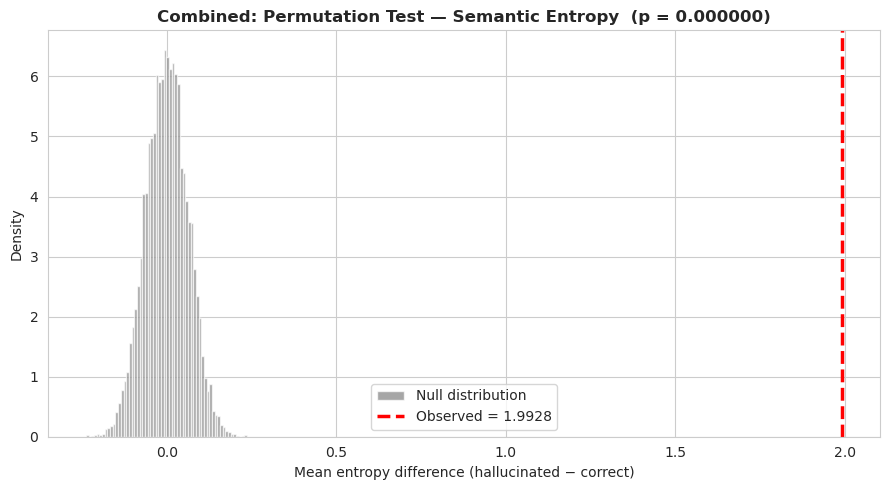

In [20]:
delta_all, perm_d_all, pval_all = run_permutation_test(
    feat_all, n_permutations=N_PERMUTATIONS, random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(perm_d_all, delta_all, N_PERMUTATIONS, pval_all,
                            title='Combined: Permutation Test — Semantic Entropy')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_permutation_test.png'), dpi=150, bbox_inches='tight')
plt.show()


### Combined: Bootstrap AUC


Bootstrap AUC (RF, 7 geometric features, B=2000):
  AUC = 0.9423  95% CI [0.9290, 0.9543]


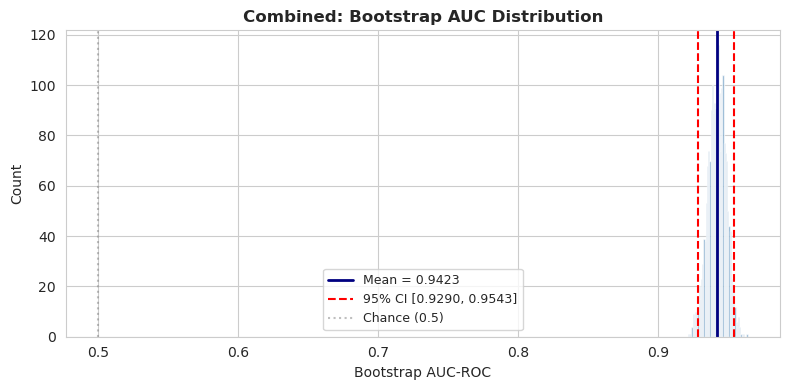

In [21]:
auc_boot_all, ci_lo_all, ci_hi_all = run_bootstrap_auc(
    feat_all, n_bootstrap=N_BOOTSTRAP, random_seed=RANDOM_SEED,
)
fig = plot_bootstrap_auc(auc_boot_all, ci_lo_all, ci_hi_all, dataset_name='Combined')
plt.savefig(os.path.join(OUTPUT_DIR, 'combined_bootstrap_auc.png'), dpi=150, bbox_inches='tight')
plt.show()


### Cross-Benchmark Summary Table


In [22]:
# Summarise KS and permutation results across all benchmarks
summary_rows = []
for ds in ['defan', 'halueval', 'mmlu', 'triviaqa', 'truthfulqa']:
    feat_df = feat_dfs[ds]
    ks_df = pd.read_csv(os.path.join(OUTPUT_DIR, f'{ds}_ks_global.csv'))
    n_sig = ks_df['Significant'].sum()
    best_ks = ks_df.loc[ks_df['KS_stat'].idxmax(), 'Feature']
    delta = eval(f'delta_{ds}')
    pval  = eval(f'pval_{ds}')
    auc_m = eval(f'auc_boot_{ds}').mean()
    lo    = eval(f'ci_lo_{ds}')
    hi    = eval(f'ci_hi_{ds}')
    summary_rows.append({
        'Dataset': ds, 'N_questions': len(feat_df),
        'Hallu_rate': f"{feat_df['label'].mean()*100:.1f}%",
        'KS_sig_features': n_sig, 'Best_KS_feature': best_ks,
        'Perm_delta_bits': round(delta, 4), 'Perm_pval': round(pval, 6),
        'Bootstrap_AUC': f"{auc_m:.3f} [{lo:.3f}, {hi:.3f}]",
    })
# Add combined
ks_all = pd.read_csv(os.path.join(OUTPUT_DIR, 'combined_ks_global.csv'))
summary_rows.append({
    'Dataset': 'combined', 'N_questions': len(feat_all),
    'Hallu_rate': f"{feat_all['label'].mean()*100:.1f}%",
    'KS_sig_features': ks_all['Significant'].sum(),
    'Best_KS_feature': ks_all.loc[ks_all['KS_stat'].idxmax(), 'Feature'],
    'Perm_delta_bits': round(delta_all, 4), 'Perm_pval': round(pval_all, 6),
    'Bootstrap_AUC': f"{auc_boot_all.mean():.3f} [{ci_lo_all:.3f}, {ci_hi_all:.3f}]",
})
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'stats_summary.csv'), index=False)
display(df_summary)


,Dataset,N_questions,Hallu_rate,KS_sig_features,Best_KS_feature,Perm_delta_bits,Perm_pval,Bootstrap_AUC
0,defan,500,79.6%,5,M_bar,1.6747,0.0,"0.905 [0.864, 0.940]"
1,halueval,500,7.2%,7,sig2_S,1.2933,0.0,"0.869 [0.785, 0.941]"
2,mmlu,500,78.4%,5,M_bar,0.3847,0.0,"0.902 [0.846, 0.947]"
3,triviaqa,500,41.6%,7,M_bar,2.0118,0.0,"0.968 [0.946, 0.988]"
4,truthfulqa,500,72.0%,5,M_bar,1.1194,0.0,"0.922 [0.885, 0.956]"
5,combined,2500,55.8%,7,H_sem,1.9928,0.0,"0.942 [0.929, 0.954]"
